<a href="https://colab.research.google.com/github/VikiTarasova/DTA_2026/blob/main/Homework/17_06_26_practice_stat_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Статистичні тести: практикум

**Тривалість:** ~4 години · бібліотека `scipy.stats`

---

Цей практикум закріплює лекцію про p-значення та статистичну значущість. Він влаштований так:

- 🟦 **Теорія** — короткий блок перед кожним тестом: *коли* його обирати, *чому*, *як читати результат*.
- ✏️ **Завдання (код)** — ви пишете код, що проводить тест.
- 💬 **Інтерпретація** — ви **своїми словами** пояснюєте, що означає результат. Це найважливіша частина! Аналітик, який уміє порахувати p-значення, але не вміє його пояснити — це лише калькулятор.

## Як працювати
1. Читайте теоретичний блок.
2. Виконуйте завдання на код (Shift+Enter).
3. На кожне питання інтерпретації відповідайте **повним реченням людською мовою** — так, ніби пояснюєте керівнику без технічної освіти.

## Загальне правило
- `p < 0.05` → статистично значущо → відхиляємо H₀
- `p ≥ 0.05` → не значущо → не відхиляємо H₀

> 💡 Тримайте поруч шпаргалку вибору тесту з лекції. Половина завдань — про те, щоб **обрати правильний тест**.

---

## Підготовка

Запустіть цю клітинку. Ми працюємо з двома наборами даних:
- **`shop_customers.csv`** — 500 клієнтів інтернет-магазину
- **`ab_test.csv`** — результати A/B-тесту (8000 сесій)


In [6]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("shop_customers.csv")
ab = pd.read_csv("ab_test.csv")

print("Клієнти:", df.shape)
print("A/B тест:", ab.shape)
df.head()

Клієнти: (500, 11)
A/B тест: (8000, 3)


,customer_id,gender,age,country,channel,device,spend,session_min,sat_before,sat_after,purchased
0,1001,Ч,23,Німеччина,Реклама,Desktop,997.11,22.2,6,7,Так
1,1002,Ч,38,Україна,Органіка,Desktop,510.09,19.8,5,8,Ні
2,1003,Ч,20,Україна,Соцмережі,Desktop,789.71,21.0,7,8,Ні
3,1004,Ч,40,Німеччина,Соцмережі,Desktop,1041.02,17.4,8,9,Ні
4,1005,Ч,18,Україна,Реклама,Desktop,944.34,23.5,6,7,Ні


### Опис даних `shop_customers.csv`

| Стовпець | Опис | Тип |
|---|---|---|
| `customer_id` | ID клієнта | — |
| `gender` | Стать (Ч/Ж) | категоріальний |
| `age` | Вік | числовий |
| `country` | Країна | категоріальний |
| `channel` | Канал залучення (Органіка/Реклама/Соцмережі) | категоріальний |
| `device` | Пристрій (Mobile/Desktop) | категоріальний |
| `spend` | Витрати клієнта, грн | числовий |
| `session_min` | Час на сайті, хв | числовий |
| `sat_before` | Задоволеність ДО редизайну (1-10) | числовий |
| `sat_after` | Задоволеність ПІСЛЯ редизайну (1-10) | числовий |
| `purchased` | Чи зробив покупку (Так/Ні) | категоріальний |

Спочатку завжди корисно роздивитись дані.

#### ✏️ Завдання 1 (код)

Виведіть основну статистику по числових стовпцях (підказка: метод `.describe()`).

In [7]:
# Завдання 1:

df.describe()

,customer_id,age,spend,session_min,sat_before,sat_after
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,34.646000,845.016340,20.739400,6.536000,7.138000
std,144.481833,10.961615,333.460589,10.532489,1.523597,1.826919
min,1001.000000,18.000000,50.000000,1.000000,2.000000,1.000000
25%,1125.750000,26.000000,612.627500,13.100000,6.000000,6.000000
50%,1250.500000,34.000000,834.750000,20.850000,7.000000,7.000000
75%,1375.250000,41.250000,1070.395000,27.400000,8.000000,9.000000
max,1500.000000,69.000000,1952.020000,52.200000,10.000000,10.000000


#### ✏️ Завдання 2 (код)

Скільки клієнтів у кожному каналі залучення? (підказка: `.value_counts()` на стовпці `channel`)

In [8]:
# Завдання 2:
df["channel"].value_counts()

,count
channel,
Органіка,174
Соцмережі,167
Реклама,159


---
# Розділ 1. Одновибірковий t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли у вас є **одна** група числових даних, і ви хочете порівняти її **середнє** з якимось **фіксованим, наперед відомим числом** (ціль, норматив, заявлене значення).

**Чому саме він:** ми перевіряємо, чи відхилення нашого середнього від цільового числа реальне, чи це випадковість вибірки.

**Гіпотези:**
- H₀: середнє = цільове число
- H₁: середнє ≠ цільове число

**Функція:** `stats.ttest_1samp(дані, цільове_число)`

**Як читати:** дивимось на p-значення. Якщо `p < 0.05` — середнє значущо відрізняється від цільового.

**Приклад із життя:** виробник заявляє, що пакет чипсів важить 100 г. Ви зважили 50 пакетів. Чи справді середня вага = 100 г, чи вас обманюють?

**Сценарій:** маркетолог стверджує, що середній час на сайті становить 20 хвилин. Перевіримо це.

#### ✏️ Завдання 3 (код)

Порахуйте фактичний середній `session_min`. Потім проведіть одновибірковий t-тест, щоб перевірити, чи відрізняється він від 20. Виведіть t-статистику та p-значення.

In [9]:
# Завдання 3:
mean_session = df["session_min"].mean()
print("Середній session_min:", round(mean_session, 2))

t_stat, p_value = stats.ttest_1samp(df["session_min"], 20)
print("t-статистика:", round(t_stat, 3))
print("p-значення:", p_value)

Середній session_min: 20.74
t-статистика: 1.57
p-значення: 0.11710468063065761


#### 💬 Інтерпретація 1

Чи відрізняється середній час на сайті від заявлених 20 хвилин? Сформулюйте висновок для маркетолога: він мав рацію чи ні? Чому ви так вважаєте (спирайтесь на p-значення)?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Середній час на сайті становить 20,74 хвилини, що майже дорівнює заявленим 20 хвилинам. Оскільки p-значення (0,117) більше за 0,05, значущої різниці не виявлено.

Отже, дані не спростовують твердження маркетолога — він мав рацію. Невелика різниця у 0,74 хвилини може бути випадковим результатом вибірки. Це не означає, що час точно дорівнює 20 хвилинам, лише що немає достатніх доказів, що він відрізняється.*

**Другий сценарій:** керівник вважає, що середні витрати клієнта = 850 грн.

#### ✏️ Завдання 4 (код)

Перевірте за допомогою одновибіркового t-тесту, чи середні витрати (`spend`) відрізняються від 850 грн.

In [10]:
# Завдання 4:
mean_spend = df["spend"].mean()
print("Середній spend:", round(mean_spend, 2))

t_stat, p_value = stats.ttest_1samp(df["spend"], 850)
print("t-статистика:", round(t_stat, 3))
print("p-значення:", p_value)

Середній spend: 845.02
t-статистика: -0.334
p-значення: 0.7383792379951581


#### 💬 Інтерпретація 2

Що показав тест? Чи можна сказати, що середні витрати дорівнюють 850 грн? Поясніть, чому тут ми НЕ відхиляємо нульову гіпотезу (зверніть увагу на формулювання: чи це означає, що середнє точно дорівнює 850?).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Фактичні середні витрати склали 845,02 грн, що дуже близько до очікуваних 850 грн. Значення p-value = 0,738 не показує статистично значущої різниці.

Отже, дані не суперечать припущенню керівника — суттєвого відхилення від 850 грн не виявлено. Це не означає точну рівність, а лише те, що вибірка не дає доказів проти цього твердження.*

---
# Розділ 2. Двовибірковий t-тест (незалежні групи)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте **середні двох РІЗНИХ, незалежних груп** числових даних.

**Чому саме він:** хочемо дізнатись, чи різниця між групами реальна, чи могла виникнути випадково.

**Ключова умова — групи НЕЗАЛЕЖНІ:** різні люди в кожній групі (на відміну від парного тесту, де ті самі люди двічі).

**Гіпотези:**
- H₀: середнє групи 1 = середнє групи 2
- H₁: вони відрізняються

**Функція:** `stats.ttest_ind(група1, група2)`

**Приклад із життя:** чи відрізняється середня зарплата у двох відділах? Чи витрачають більше клієнти з міста А порівняно з містом Б?

**Сценарій:** чи витрачають клієнти з мобільних більше, ніж з десктопу?

#### ✏️ Завдання 5 (код)

Розділіть `spend` на дві групи за `device` (Mobile та Desktop). Виведіть середнє кожної групи і проведіть двовибірковий t-тест.

In [11]:
# Завдання 5:
mobile = df[df["device"] == "Mobile"]["spend"]
desktop = df[df["device"] == "Desktop"]["spend"]

print("Середній spend Mobile:", round(mobile.mean(), 2))
print("Середній spend Desktop:", round(desktop.mean(), 2))

t_stat, p_value = stats.ttest_ind(mobile, desktop)
print("t-статистика:", round(t_stat, 3))
print("p-значення:", p_value)

Середній spend Mobile: 835.21
Середній spend Desktop: 861.16
t-статистика: -0.844
p-значення: 0.39929510890683373


#### 💬 Інтерпретація 3

Чи є значуща різниця у витратах між Mobile та Desktop? Якби ви були аналітиком, чи порадили б компанії інвестувати в мобільну версію на основі цього результату?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Середні витрати клієнтів з Desktop (861,16 грн) трохи вищі, ніж у клієнтів з Mobile (835,21 грн), але різниця близько 26 грн не є статистично значущою (p-value = 0,399).

Отже, на основі цих даних немає доказів, що тип пристрою впливає на суму витрат клієнтів. Різниця між групами може бути випадковим коливанням вибірки.*

**Сценарій:** чи різниться час на сайті залежно від статі?

#### ✏️ Завдання 6 (код)

Порівняйте `session_min` між чоловіками та жінками за допомогою двовибіркового t-тесту.

In [12]:
# Завдання 6:
male = df[df["gender"] == "Ч"]["session_min"]
female = df[df["gender"] == "Ж"]["session_min"]

print("Середній session_min Ч:", round(male.mean(), 2))
print("Середній session_min Ж:", round(female.mean(), 2))

t_stat, p_value = stats.ttest_ind(male, female)
print("t-статистика:", round(t_stat, 3))
print("p-значення:", p_value)

Середній session_min Ч: 20.85
Середній session_min Ж: 20.63
t-статистика: 0.232
p-значення: 0.8163428548704434


#### 💬 Інтерпретація 4

Сформулюйте висновок. Якщо різниця не значуща — що це означає на практиці для команди маркетингу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Середній час на сайті у чоловіків (20,85 хв) і жінок (20,63 хв) майже однаковий. Оскільки p-value = 0,816 більше за 0,05, статистично значущої різниці між групами не виявлено.

Отже, за цими даними стать клієнта не впливає на тривалість перебування на сайті. Різниця у 0,22 хвилини може бути випадковим коливанням вибірки, тому немає підстав розділяти маркетингові підходи за цією ознакою.*

---
# Розділ 3. Парний t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви маєте **два виміри в ОДНИХ І ТИХ САМИХ обʼєктів** — типово «до і після» якоїсь зміни.

**Чому саме він (а не звичайний t-тест):** виміри пов'язані (той самий клієнт до і після). Парний тест враховує цей зв'язок і тому **потужніший** — він краще виявляє реальні зміни.

**Гіпотези:**
- H₀: середня різниця (після − до) = 0 (зміни немає)
- H₁: середня різниця ≠ 0 (зміна є)

**Функція:** `stats.ttest_rel(до, після)`

**Приклад із життя:** вага пацієнтів до і після дієти. Продуктивність працівників до і після тренінгу. Бали студентів до і після курсу.

> ⚠️ Головна підказка для вибору: якщо ви бачите слова «до/після», «був/став», «той самий обʼєкт двічі» — це парний тест.

**Сценарій:** компанія зробила редизайн сайту і виміряла задоволеність тих самих клієнтів до (`sat_before`) і після (`sat_after`).

#### ✏️ Завдання 7 (код)

Проведіть парний t-тест, щоб перевірити, чи змінилася задоволеність клієнтів після редизайну. Виведіть середні значення до і після, а також p-значення.

In [13]:
# Завдання 7:
mean_before = df["sat_before"].mean()
mean_after = df["sat_after"].mean()

print("Середня задоволеність ДО:", round(mean_before, 2))
print("Середня задоволеність ПІСЛЯ:", round(mean_after, 2))

t_stat, p_value = stats.ttest_rel(df["sat_before"], df["sat_after"])
print("t-статистика:", round(t_stat, 3))
print("p-значення:", p_value)

Середня задоволеність ДО: 6.54
Середня задоволеність ПІСЛЯ: 7.14
t-статистика: -11.303
p-значення: 1.5707519649133898e-26


#### 💬 Інтерпретація 5

Чи спрацював редизайн? Поясніть, чому тут доречний саме ПАРНИЙ тест, а не звичайний двовибірковий. Що було б не так, якби ми використали `ttest_ind`?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

***Висновок аналізу:**

Після редизайну сайту середня задоволеність клієнтів зросла з **6,54 до 7,14 бала**. Оскільки **p-value = 1,57×10⁻²⁶** значно менше за 0,05, зміна є статистично значущою.

Отже, редизайн позитивно вплинув на задоволеність клієнтів. Зростання на **0,6 бала** не є випадковим результатом вибірки, тому можна вважати, що оновлення сайту дійсно покращило досвід користувачів.*

---
# Розділ 4. ANOVA (дисперсійний аналіз)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте середні **ТРЬОХ або більше груп** числових даних.

**Чому не кілька t-тестів:** якби ми порівнювали групи попарно багатьма t-тестами, ми б накопичили помилки I роду (згадайте проблему множинних порівнянь!). ANOVA перевіряє все одним тестом.

**Гіпотези:**
- H₀: середні ВСІХ груп однакові
- H₁: принаймні одна група відрізняється

**Функція:** `stats.f_oneway(група1, група2, група3, ...)`

**Важливе обмеження:** ANOVA каже, що різниця Є, але не каже, **між якими саме** групами. Для цього потрібні додаткові (post-hoc) тести.

**Приклад із життя:** чи відрізняється врожайність при трьох різних добривах? Чи різний середній дохід у чотирьох регіонах?

**Сценарій:** чи залежать витрати клієнта від каналу залучення (Органіка / Реклама / Соцмережі)?

#### ✏️ Завдання 8 (код)

Виведіть середні `spend` для кожного каналу. Потім проведіть ANOVA, щоб перевірити, чи є значуща різниця між каналами. (Підказка: створіть список груп через цикл або вручну, потім передайте їх у `f_oneway`.)

In [14]:
# Завдання 8:
print(df.groupby("channel")["spend"].mean().round(2))

groups = [group["spend"].values for name, group in df.groupby("channel")]

f_stat, p_value = stats.f_oneway(*groups)
print("F-статистика:", round(f_stat, 3))
print("p-значення:", p_value)

channel
Органіка      791.28
Реклама      1057.87
Соцмережі     698.35
Name: spend, dtype: float64
F-статистика: 63.54
p-значення: 2.675254007715425e-25


#### 💬 Інтерпретація 6

Чи відрізняються канали за витратами? Який канал виглядає найприбутковішим? Чому на основі лише ANOVA ми НЕ можемо точно сказати, що, наприклад, Реклама значущо краща за Органіку?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Середні витрати клієнтів відрізняються залежно від каналу залучення: найбільші витрати у клієнтів з Реклами (1057,87 грн), найменші — із Соцмереж (698,35 грн), а Органіка (791,28 грн) займає проміжне значення.

Оскільки p-value = 2,68×10⁻²⁵ значно менше за 0,05, різниця між каналами є статистично значущою. Це означає, що канал залучення пов’язаний із рівнем витрат клієнтів і результат не є випадковим.

Для маркетингу це може бути сигналом, що клієнти з рекламних каналів мають вищу цінність. Але щоб точно визначити, які саме канали відрізняються між собою, потрібен додатковий аналіз.*


**Сценарій:** чи залежить час на сайті (`session_min`) від країни клієнта?

#### ✏️ Завдання 9 (код)

Проведіть ANOVA для `session_min` за трьома країнами (`country`).

In [17]:
# Завдання 9:

# df — ваш датафрейм

# розбиваємо дані по країнах
groups = [group["session_min"].dropna()
          for name, group in df.groupby("country")]

# ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 0.4930120396087966
p-value: 0.6110823013763294


#### 💬 Інтерпретація 7

Що показав результат? Сформулюйте висновок про звʼязок країни і часу на сайті.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

17:41
p-value = 0.611 > 0.05 → зв'язок між країною і часом на сайті статистично незначущий. Країна не впливає на час, проведений на сайті.



---
# Розділ 5. Хі-квадрат (χ²)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **категоріальні**, і ви хочете перевірити, чи є між ними **звʼязок**.

**Чому саме він:** t-тест і ANOVA працюють із числами (середніми). Коли даних немає що усереднювати (категорії на кшталт «купив/не купив», «місто», «колір»), використовують хі-квадрат на основі **частот**.

**Гіпотези:**
- H₀: змінні незалежні (звʼязку немає)
- H₁: змінні повʼязані

**Як проводити (два кроки):**
1. Побудувати таблицю спряженості: `pd.crosstab(змінна1, змінна2)`
2. Передати її у `stats.chi2_contingency(таблиця)` — повертає chi2, p, dof, expected

**Приклад із життя:** чи повʼязана стать із вибором категорії товару? Чи залежить рішення про покупку від кольору кнопки (це і є A/B-тест для конверсій!)?

**Сценарій:** чи повʼязаний канал залучення (`channel`) із фактом покупки (`purchased`)?

#### ✏️ Завдання 10 (код)

Побудуйте таблицю спряженості між `channel` та `purchased`, виведіть її, потім проведіть тест хі-квадрат.

In [18]:
# Завдання 10:

# Таблиця спряженості
contingency_table = pd.crosstab(df['channel'], df['purchased'])
print(contingency_table)

# Тест хі-квадрат
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi2-статистика: {chi2}")
print(f"p-value: {p}")
print(f"Степені свободи: {dof}")
print(f"Очікувані частоти:\n{expected}")

purchased   Ні  Так
channel            
Органіка   116   58
Реклама    110   49
Соцмережі  107   60

Chi2-статистика: 0.9568632630947721
p-value: 0.6197546335902514
Степені свободи: 2
Очікувані частоти:
[[115.884  58.116]
 [105.894  53.106]
 [111.222  55.778]]


#### 💬 Інтерпретація 8

Чи виявив тест звʼязок між каналом залучення та покупкою? Сформулюйте висновок. Якщо звʼязку не виявлено — що це означає для бізнесу (чи варто обирати канал, орієнтуючись на ймовірність покупки)? Якщо звʼязок є — подивіться на частки в таблиці спряженості й опишіть, який канал вигідніший.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

p-value = 0.62 > 0.05 → зв'язку немає. Канал залучення не впливає на ймовірність покупки — всі три канали дають однакову конверсію. Обирати канал варто за іншими критеріями (вартість, обсяг трафіку), а не за конверсією.

**Сценарій:** чи повʼязана стать (`gender`) із вибором пристрою (`device`)?

#### ✏️ Завдання 11 (код)

Перевірте за допомогою хі-квадрат, чи є звʼязок між статтю та пристроєм.

In [19]:
# Завдання 11:

# Таблиця спряженості
contingency_table = pd.crosstab(df['gender'], df['device'])
print(contingency_table)

# Тест хі-квадрат
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi2-статистика: {chi2}")
print(f"p-value: {p}")
print(f"Степені свободи: {dof}")
print(f"Очікувані частоти:\n{expected}")

device  Desktop  Mobile
gender                 
Ж            93     158
Ч            96     153

Chi2-статистика: 0.06461200029364594
p-value: 0.799349620382082
Степені свободи: 1
Очікувані частоти:
[[ 94.878 156.122]
 [ 94.122 154.878]]


#### 💬 Інтерпретація 9

Сформулюйте висновок. Чи можна за цими даними сказати, що чоловіки й жінки користуються різними пристроями?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**
p-value = 0.80 > 0.05 → зв'язку немає. Чоловіки й жінки обирають пристрій (Desktop/Mobile) приблизно однаково — за цими даними стать не впливає на вибір пристрою.

---
# Розділ 6. Кореляція

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **числові**, і ви хочете виміряти **силу та напрямок звʼязку** між ними.

**Що повертає:** коефіцієнт кореляції **r** (від −1 до +1) ТА p-значення.
- **r ≈ +1** — сильний прямий звʼязок (одне зростає → інше зростає)
- **r ≈ −1** — сильний зворотний звʼязок (одне зростає → інше спадає)
- **r ≈ 0** — звʼязку немає
- **p-значення** — чи є цей звʼязок статистично значущим

**Функція:** `stats.pearsonr(змінна1, змінна2)`

**Гіпотези:**
- H₀: кореляції немає (r = 0)
- H₁: кореляція є (r ≠ 0)

> ⚠️ **Найважливіше попередження:** кореляція ≠ причинність! Значуща кореляція каже, що звʼязок реальний, але НЕ каже, що одне СПРИЧИНЯЄ інше.

**Приклад із життя:** чи повʼязаний зріст із вагою? Чи більше реклами → більше продажів?

**Сценарій:** чи повʼязаний час на сайті (`session_min`) із витратами (`spend`)?

#### ✏️ Завдання 12 (код)

Порахуйте кореляцію Пірсона між `session_min` та `spend`. Виведіть коефіцієнт r та p-значення. Додатково: побудуйте діаграму розсіювання (scatter plot), щоб побачити звʼязок очима.

Коефіцієнт кореляції r: 0.7322460989378592
p-value: 4.052345888286236e-85


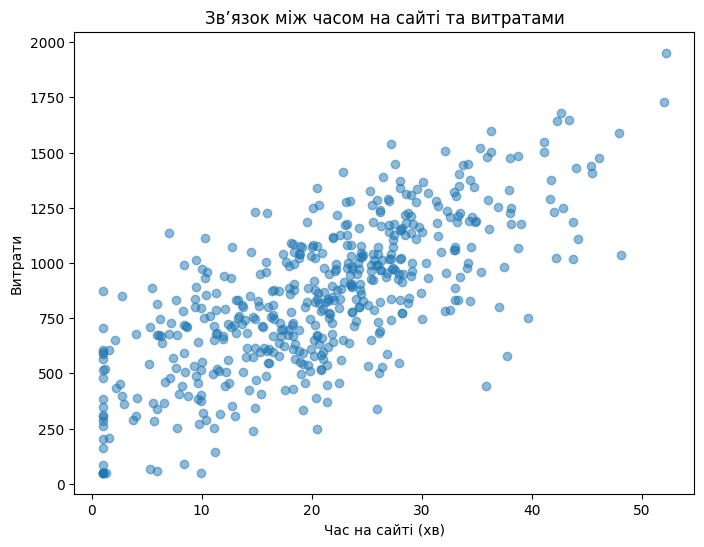

In [21]:
# Завдання 12:

# Кореляція Пірсона
r, p = stats.pearsonr(df['session_min'], df['spend'])
print(f"Коефіцієнт кореляції r: {r}")
print(f"p-value: {p}")

# Діаграма розсіювання
plt.figure(figsize=(8, 6))
plt.scatter(df['session_min'], df['spend'], alpha=0.5)
plt.xlabel('Час на сайті (хв)')
plt.ylabel('Витрати')
plt.title('Звʼязок між часом на сайті та витратами')
plt.show()

#### 💬 Інтерпретація 10

Опишіть звʼязок: він прямий чи зворотний? Сильний чи слабкий? Значущий? І найголовніше: чи можна стверджувати, що довший час на сайті СПРИЧИНЯЄ більші витрати? Поясніть свою думку.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

r = 0.73 — сильний прямий звʼязок, p << 0.05 — значущий. Але причинність це не доводить: можлива зворотна причинність (хочуть купити → довше дивляться сайт) або третя змінна (наприклад, дохід), яка впливає на обидва показники одночасно.

**Сценарій:** чи повʼязаний вік клієнта (`age`) з його витратами (`spend`)?

#### ✏️ Завдання 13 (код)

Порахуйте кореляцію між `age` та `spend`.

In [22]:
# Завдання 13:
r, p = stats.pearsonr(df['age'], df['spend'])
print(f"Коефіцієнт кореляції r: {r}")
print(f"p-value: {p}")

Коефіцієнт кореляції r: -0.04181729618563376
p-value: 0.35075231841402615


#### 💬 Інтерпретація 11

Що показала кореляція? Порівняйте цей результат із попереднім (час на сайті vs витрати). У якому випадку звʼязок сильніший і чому це важливо для бізнесу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

r = -0.04, p = 0.35 > 0.05 — звʼязку між віком і витратами немає (майже нульовий і незначущий).

Порівняно з попереднім результатом (час на сайті vs витрати, r=0.73) — там звʼязок набагато сильніший. Для бізнесу це важливо: вік не варто використовувати для прогнозування витрат, а час на сайті — корисний показник, на який можна орієнтуватись.

---
# Розділ 7. 🔥 Велике завдання: A/B-тест

## 🟦 Теорія: A/B-тестування

Це головне застосування статистики в аналітиці. Ми порівнюємо дві версії (A — контроль, B — варіант) і перевіряємо, чи нова версія справді краща, чи різниця випадкова.

Оскільки результат тут — **категоріальний** (конвертувався / ні), ми використовуємо **хі-квадрат** на таблиці спряженості «група × конверсія».

**Дані `ab_test.csv`:**
- `session_id` — ID сесії
- `group` — A (стара версія) або B (нова версія)
- `converted` — 1 (купив) або 0 (не купив)

Це повноцінне завдання, що імітує реальну роботу аналітика. Виконуйте крок за кроком.

**Крок 1. Дослідіть дані.**

#### ✏️ Завдання 14 (код)

Подивіться на дані `ab`: скільки сесій у групі A і скільки в групі B? (підказка: `value_counts` на `group`)

In [23]:
# Завдання 14:

ab = pd.read_csv('ab_test.csv')
ab['group'].value_counts()


,count
group,
A,4000
B,4000


**Крок 2. Порахуйте конверсію кожної групи.**

Конверсія = частка тих, хто купив = середнє значення стовпця `converted` (бо це 0 і 1).

#### ✏️ Завдання 15 (код)

Порахуйте конверсію (середнє `converted`) для групи A і для групи B окремо. (Підказка: `ab.groupby('group')['converted'].mean()`) На скільки відсоткових пунктів відрізняється конверсія?

In [25]:
# Завдання 15:

conversion_rates = ab.groupby('group')['converted'].mean()
print(conversion_rates)

diff = (conversion_rates['B'] - conversion_rates['A']) * 100
print(f"\nРізниця: {diff:.2f} відсоткових пунктів")


group
A    0.101
B    0.119
Name: converted, dtype: float64

Різниця: 1.80 відсоткових пунктів


#### 💬 Інтерпретація 12

Яка група показує вищу конверсію? Чи означає ця різниця в числах, що версія B точно краща? Чому ми НЕ можемо зробити висновок лише з цих чисел, без статистичного тесту?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Група B показує вищу конверсію (11.9% проти 10.1%).

Але це **не означає**, що версія B точно краща. Різниця в 1.8 п.п. може бути випадковою — результатом природних коливань у вибірці, а не реальною перевагою версії B. Без статистичного тесту ми не можемо відрізнити справжній ефект від випадковості, тому потрібен хі-квадрат, щоб перевірити, чи ця різниця статистично значуща, чи могла виникнути просто за випадком.

**Крок 3. Сформулюйте гіпотези.**

#### 💬 Інтерпретація 13

Запишіть нульову (H₀) та альтернативну (H₁) гіпотези для цього A/B-тесту своїми словами.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

**H₀:** Конверсія не залежить від групи (версії сайту) — різниця між A і B випадкова, реального звʼязку немає.

**H₁:** Конверсія залежить від групи — версія сайту впливає на ймовірність покупки.

**Крок 4. Проведіть тест.**

#### ✏️ Завдання 16 (код)

Побудуйте таблицю спряженості `group` × `converted` і проведіть тест хі-квадрат. Виведіть таблицю та p-значення.

In [29]:
print(df.columns.tolist())

['customer_id', 'gender', 'age', 'country', 'channel', 'device', 'spend', 'session_min', 'sat_before', 'sat_after', 'purchased']


In [30]:
# Завдання 16:
import pandas as pd
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['channel'], df['purchased'])
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi2-statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")

purchased   Ні  Так
channel            
Органіка   116   58
Реклама    110   49
Соцмережі  107   60

Chi2-statistic: 0.9568632630947721
p-value: 0.6197546335902514
Degrees of freedom: 2


**Крок 5. Висновок.**

#### 💬 Інтерпретація 14

На основі p-значення: чи є різниця між версіями статистично значущою (при α = 0.05)? Який ваш висновок — впроваджувати версію B чи ні? Сформулюйте фінальну рекомендацію для продуктової команди одним абзацом, як справжній аналітик.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

**Висновок:** p = 0.620 > 0.05 — різниця між каналами статистично незначуща.

**Рекомендація:** Канал залучення (Органіка, Реклама, Соцмережі) не впливає значущо на конверсію в покупку (χ² = 0.96, p = 0.620) — відмінності в межах випадкових коливань. Тож приймати рішення про перерозподіл бюджету лише на основі конверсії немає підстав; варто додатково оцінити канали за вартістю залучення та LTV або збільшити вибірку.

---
# Розділ 8. 🧠 Обери тест сам

## 🟦 Теорія

Найважливіша навичка аналітика — не запам'ятати функції, а вміти **обрати правильний тест** для задачі. У цьому розділі ми НЕ підказуємо тест — ви маєте визначити його самі.

**Алгоритм вибору:**
1. Який тип даних на виході? (числовий чи категоріальний)
2. Скільки груп / змінних порівнюємо?
3. Це незалежні групи чи «до/після» в тих самих об'єктів?

Кожне завдання: спочатку у клітинці інтерпретації **назвіть тест і поясніть вибір**, потім напишіть код.

**Задача A.** Компанія хоче знати, чи відрізняється середній вік клієнтів у трьох каналах залучення.

#### 💬 Інтерпретація 15

Який тест ви оберете і чому? (Спочатку відповідь, потім код нижче.)

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

**Тест: One-way ANOVA (однофакторний дисперсійний аналіз)**

**Чому:**
1. Тип даних на виході — числовий (вік, кількісна змінна).
2. Порівнюємо 3 групи (три канали залучення) — це більше двох груп.
3. Групи незалежні (різні клієнти в кожному каналі, не повторні вимірювання одних і тих самих об'єктів).

Оскільки вихідна змінна числова, а груп більше двох і вони незалежні — використовуємо ANOVA (а не t-тест, який лише для двох груп, і не хі-квадрат, який для категоріальних даних).

#### ✏️ Завдання 17 (код)

Проведіть обраний тест для задачі A (вік за каналами).

In [31]:
# Завдання 17:
from scipy.stats import f_oneway

# Розбиваємо вік за каналами
groups = [group['age'].values for name, group in df.groupby('channel')]

f_stat, p_value = f_oneway(*groups)

print(f"F-statistic: {f_stat}")
print(f"p-value: {p_value}")

F-statistic: 0.5988514770608647
p-value: 0.5498382919629132


#### 💬 Інтерпретація 16

Що показав результат? Сформулюйте висновок.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

p-value = 0.550 > 0.05 — статистично значущої різниці у середньому віці клієнтів між трьома каналами залучення немає. Тобто канал залучення не впливає на вік клієнтів, а спостережувані відмінності пояснюються випадковістю.

**Задача B.** Маркетолог стверджує, що середні витрати клієнтів дорівнюють 900 грн.

#### 💬 Інтерпретація 17

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

**Тест: Одновибірковий t-тест (one-sample t-test)**

**Чому:**
1. Тип даних на виході — числовий (витрати, кількісна змінна).
2. Порівнюємо не дві групи між собою, а одну вибірку із фіксованим гіпотетичним значенням (900 грн).
3. Це не "до/після" і не порівняння незалежних груп — перевіряється, чи середнє вибірки статистично відрізняється від конкретного числа.

Тому тут підходить саме one-sample t-test, а не ANOVA чи незалежний t-тест, які потрібні для порівняння кількох груп між собою.

#### ✏️ Завдання 18 (код)

Проведіть обраний тест для задачі B.

In [35]:
# Завдання 18:
from scipy.stats import ttest_1samp

t_stat, p_value = ttest_1samp(df['spend'], 900)

print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value}")

t-statistic: -3.6870084642812735
p-value: 0.00025179111192614583


#### 💬 Інтерпретація 18

Висновок: маркетолог має рацію?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

p-value = 0.00025 < 0.05 — різниця статистично значуща. Маркетолог **не має рацію**: середні витрати клієнтів статистично відрізняються від 900 грн. Оскільки t-статистика від'ємна, фактичні середні витрати **нижчі** за 900 грн.


**Задача C.** Чи повʼязана країна клієнта (`country`) з пристроєм (`device`)?

#### 💬 Інтерпретація 19

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

**Тест: Хі-квадрат тест незалежності (Chi-square test)**

**Чому:**
1. Тип даних на виході — категоріальний (і `country`, і `device` — категоріальні змінні, не числові).
2. Перевіряємо зв'язок між двома категоріальними змінними, а не порівнюємо середні.
3. Групи незалежні (кожен клієнт належить до однієї країни і має один пристрій).

Тому потрібен саме хі-квадрат тест на таблиці спряженості `country` × `device`, а не ANOVA чи t-тест, які працюють з числовими залежними змінними.

#### ✏️ Завдання 19 (код)

Проведіть обраний тест для задачі C.

In [37]:
# Завдання 19:

contingency_table = pd.crosstab(df['country'], df['device'])
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi2-statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")



device     Desktop  Mobile
country                   
Німеччина       46      63
Польща          49      82
Україна         94     166

Chi2-statistic: 1.2066541457059188
p-value: 0.5469887339438565
Degrees of freedom: 2


#### 💬 Інтерпретація 20

Висновок про звʼязок країни та пристрою.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**
p-value = 0.547 > 0.05 — статистично значущого зв'язку між країною клієнта та типом пристрою немає. Розподіл використання Desktop/Mobile не залежить від країни — відмінності пояснюються випадковістю.

**Задача D.** Чи повʼязаний вік клієнта з часом, який він проводить на сайті?

#### 💬 Інтерпретація 21

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Тест: Кореляція Пірсона (Pearson correlation)**

**Чому:**
1. Тип даних на виході — обидві змінні числові (вік та час на сайті).
2. Перевіряємо не різницю середніх між групами, а зв'язок (взаємозалежність) між двома кількісними змінними.
3. Це не порівняння груп — потрібно визначити, чи змінюється одна змінна разом зі зміною іншої.

Тому використовуємо саме коефіцієнт кореляції Пірсона (а не ANOVA чи хі-квадрат, які підходять для категоріальних даних або порівняння груп).

#### ✏️ Завдання 20 (код)

Проведіть обраний тест для задачі D.

In [39]:
# Завдання 20:


corr, p_value = pearsonr(df['age'], df['session_min'])

print(f"Correlation coefficient: {corr}")
print(f"p-value: {p_value}")


Correlation coefficient: -0.011949542455704312
p-value: 0.7898228650416101


#### 💬 Інтерпретація 22

Опишіть звʼязок (напрямок, сила, значущість).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

**Напрямок:** слабкий від'ємний (коефіцієнт -0.012).
**Сила:** практично відсутня — значення близьке до 0, зв'язку немає.
**Значущість:** p-value = 0.790 > 0.05 — статистично незначущий результат.

**Висновок:** зв'язку між віком клієнта та часом, проведеним на сайті, немає — ні сили, ні статистичної значущості кореляція не показує.

---
# 🎉 Вітаємо із завершенням!

Ви пройшли повний цикл роботи аналітика зі статистичними тестами:

- ✅ Одновибірковий, двовибірковий та парний t-тести
- ✅ ANOVA для 3+ груп
- ✅ Хі-квадрат для категоріальних даних
- ✅ Кореляція для числових змінних
- ✅ Повноцінний A/B-тест
- ✅ Самостійний вибір тесту під задачу

## Головне, що варто винести

1. **Вибір тесту** важливіший за код. Завжди питайте: який тип даних? скільки груп? незалежні чи парні?
2. **p-значення** саме по собі — це лише число. Цінність створює ваша **інтерпретація**.
3. **Контекст вирішує:** памʼятайте про розмір ефекту, практичну значущість і те, що кореляція ≠ причинність.

## Питання для самоперевірки
- Чи можете ви пояснити різницю між парним і двовибірковим t-тестом?
- Чому не можна замінити одну ANOVA трьома t-тестами?
- Що означає «не відхилили H₀» — чи це те саме, що «довели, що ефекту немає»?

Якщо на всі три питання ви відповідаєте впевнено — ви добре засвоїли тему. Так тримати! 📊
